# Cell Segmentation Demo - BBBC018 Dataset

This notebook demonstrates cell and nuclei segmentation on the BBBC018 dataset using CellPose pretrained models.

## 1. Setup Environment

To ensure reproducibility, install the required libraries from the requirements.txt file.

In [1]:
!pip install -r ../requirements.txt

     |████████████████████████████████| 13.4 MB 9.3 MB/s eta 0:00:01
  Attempting uninstall: scikit-image
    Found existing installation: scikit-image 0.21.0
    Uninstalling scikit-image-0.21.0:
      Successfully uninstalled scikit-image-0.21.0
You should consider upgrading via the '/Users/enes/Documents/Workspace/enes_cell_segmentation/.venv/bin/python3 -m pip install --upgrade pip' command.


## 2. Import Libraries and Define Constants

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io
import imageio
from cellpose import models
import scipy.ndimage as ndi
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

# Data paths
data_dir = Path('../data/BBBC018_v1_images')
outlines_dir = Path('../data/BBBC018_v1_outlines')

## 3. Data Exploration and Loading Functions

Helper functions to discover and load the BBBC018 dataset correctly.


## Data Structure
- **Images**: 3 channels per sample (actin, DNA, pH3) stored as `.DIB` files
- **Ground Truth**: Nuclei and cell masks stored as `.png` files in the outlines folder

In [9]:
def get_available_samples():
    """
    Discover all available sample IDs in the dataset.
    Returns a sorted list of unique sample IDs.
    """
    samples = set()
    for file in data_dir.glob('*.DIB'):
        sample_id = file.stem.split('-')[0]
        samples.add(sample_id)
    return sorted(list(samples))

def load_sample_channels(sample_id):
    """
    Load all channel DIB images available for a given sample ID using imageio.
    Returns channels in order with DNA at the left.
    """
    channels = {}
    for file in sorted(data_dir.glob(f"{sample_id}-*.DIB")):
        channel_name = file.stem.split('-', 1)[-1]
        channels[channel_name] = imageio.imread(str(file))

    # if DNA exists, force it to be first
    if 'DNA' in channels:
        ordered = {'DNA': channels.pop('DNA')}
    else:
        ordered = {}

    for name in sorted(channels.keys()):
        ordered[name] = channels[name]

    return ordered

def load_ground_truth(sample_id):
    """
    Load ground truth masks (nuclei and cells) for a given sample ID.
    Flips masks with respect to x-axis for consistency with image orientation.
    Returns None for mask types that are not found.
    """
    masks = {}
    for mask_type in ['nuclei', 'cells']:
        file_path = outlines_dir / f"{sample_id}-{mask_type}.png"
        if file_path.exists():
            mask = io.imread(str(file_path))
            # Flip with respect to x-axis (vertical flip)
            masks[mask_type] = np.flipud(mask)
        else:
            print(f"Warning: {file_path} not found")
            masks[mask_type] = None  # Explicitly mark as missing
    return masks

# List available samples
available_samples = get_available_samples()
print(f"Found {len(available_samples)} samples in the dataset")
print(f"Sample IDs: {available_samples[:5]} ... (showing first 5)")

Found 56 samples in the dataset
Sample IDs: ['00733', '00734', '00735', '00736', '03997'] ... (showing first 5)


## 4. Visualize Sample Data

Load and visualize all channels plus ground truth masks for a sample.



=== Visualizing sample 07314 ===
Loaded channels for sample 07314:
  DNA: shape=(512, 512, 3), dtype=uint8, range=[0, 255]
  actin: shape=(512, 512, 3), dtype=uint8, range=[0, 255]
  pH3: shape=(512, 512, 3), dtype=uint8, range=[0, 255]

Loaded ground truth masks:
  nuclei: shape=(512, 512), dtype=bool, unique_values=2
  cells: shape=(512, 512), dtype=uint8, unique_values=15


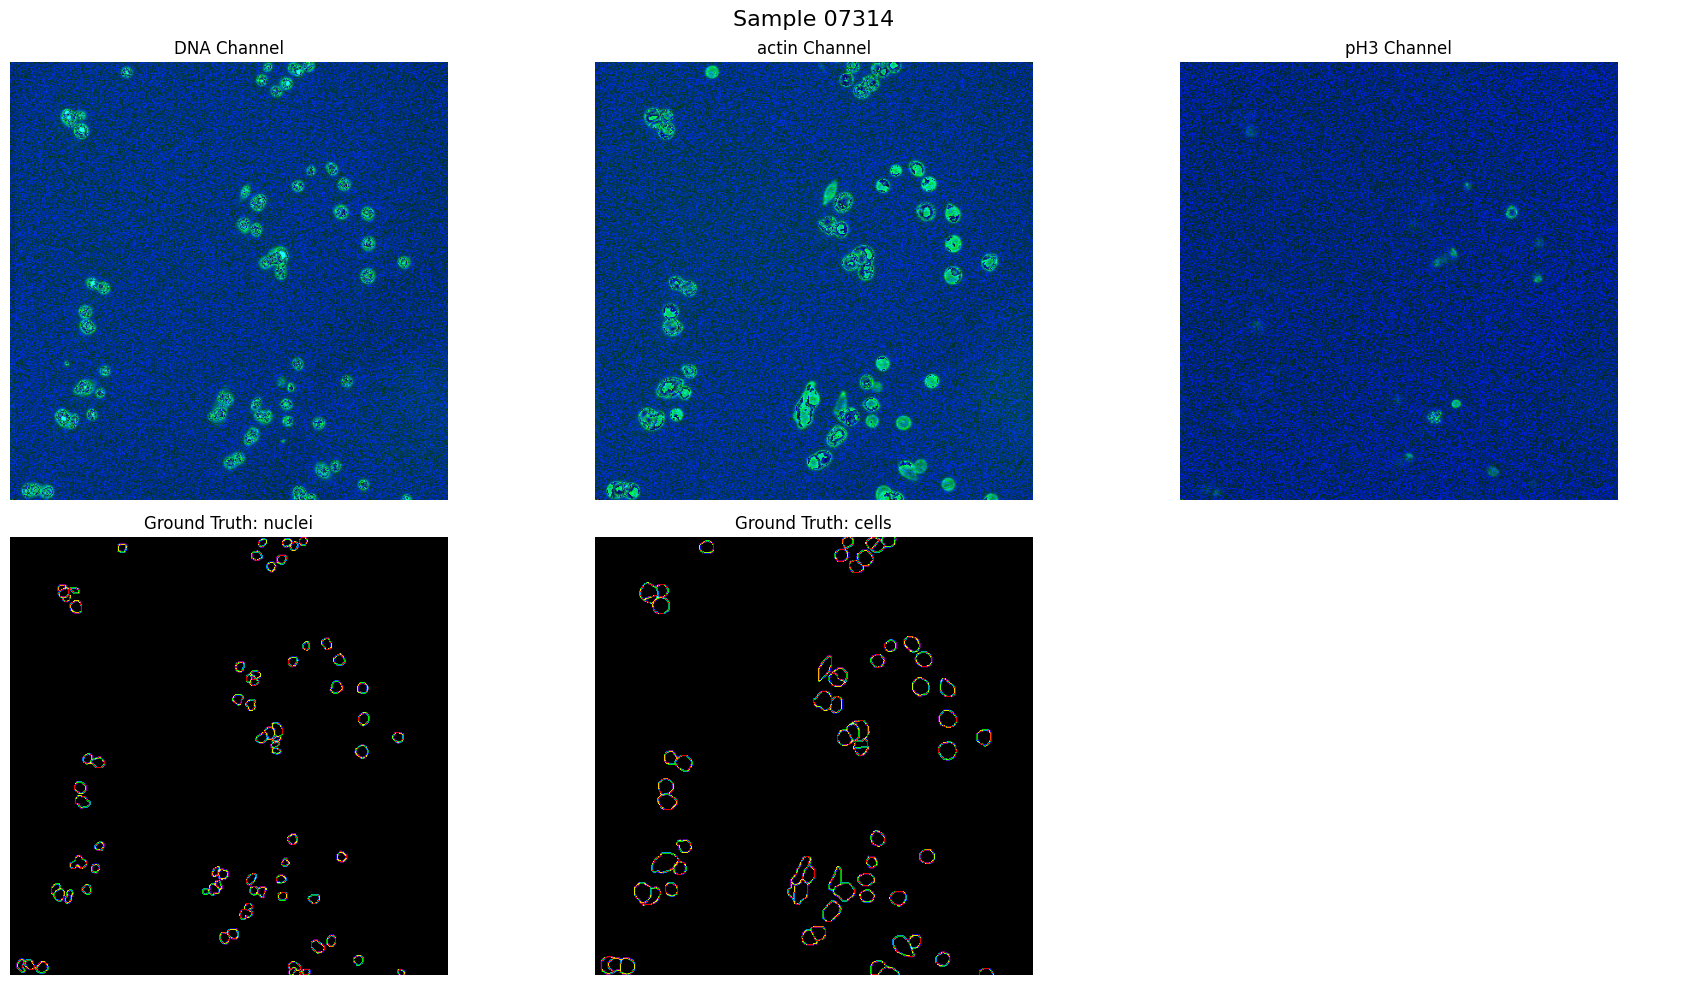

In [40]:
def visualize_sample(sample_id, channels, masks):
    """Plot channels and ground truth masks in a 2x3 grid."""
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    # Row 1: channels
    for idx, ch in enumerate(['DNA', 'actin', 'pH3']):
        ax = axes[0, idx]
        if ch in channels:
            img = channels[ch]
            if img.ndim == 2:
                img = np.stack([img] * 3, axis=-1)
            ax.imshow(img)
            ax.set_title(f'{ch} Channel')
        else:
            ax.text(0.5, 0.5, 'Missing', ha='center', va='center')
        ax.axis('off')
    
    # Row 2: ground truth masks
    for i in range(3):
        axes[1, i].axis('off')
    
    if masks.get('nuclei') is not None:
        axes[1, 0].imshow(masks['nuclei'], cmap='nipy_spectral')
        axes[1, 0].set_title('Ground Truth: nuclei')
    
    if masks.get('cells') is not None:
        axes[1, 1].imshow(masks['cells'], cmap='nipy_spectral')
        axes[1, 1].set_title('Ground Truth: cells')
    
    plt.suptitle(f'Sample {sample_id}', fontsize=16)
    plt.tight_layout()
    plt.show()

# Visualize 1 randomly selected sample
sample_ids = list(np.random.choice(available_samples, min(1, len(available_samples)), replace=False))

for sample_id in sample_ids:
    print(f"\n=== Visualizing sample {sample_id} ===")
    
    channels = load_sample_channels(sample_id)
    print(f"Loaded channels for sample {sample_id}:")
    for channel, data in channels.items():
        print(f"  {channel}: shape={data.shape}, dtype={data.dtype}, range=[{data.min()}, {data.max()}]")

    masks = load_ground_truth(sample_id)
    print(f"\nLoaded ground truth masks:")
    for mask_type, data in masks.items():
        if data is not None:
            print(f"  {mask_type}: shape={data.shape}, dtype={data.dtype}, unique_values={len(np.unique(data))}")
        else:
            print(f"  {mask_type}: NOT FOUND (None)")
    
    visualize_sample(sample_id, channels, masks)


Conclusion: 

1. pH3 Channel does not provide useful information for nuclei or cell detection.
2. The data correctness and loading is verified by visualization: images and respective ground truth match correctly.

## 5. CellPose Predictions (Nuclei and Cells)

Run the pretrained CellPose models on the loaded sample channels and compare with the ground truth outlines.

In [32]:
# Load CellPose models
model_nuclei = models.Cellpose(gpu=False, model_type='nuclei')
model_cells = models.Cellpose(gpu=False, model_type='cyto2') # preliminary prediction results show cyto2 works better than other cell segmentation models

=== Single Sample Prediction ===
Nuclei: 90 objects | IoU: 0.366, Dice: 0.535
Cells: 40 objects | IoU: 0.445, Dice: 0.616


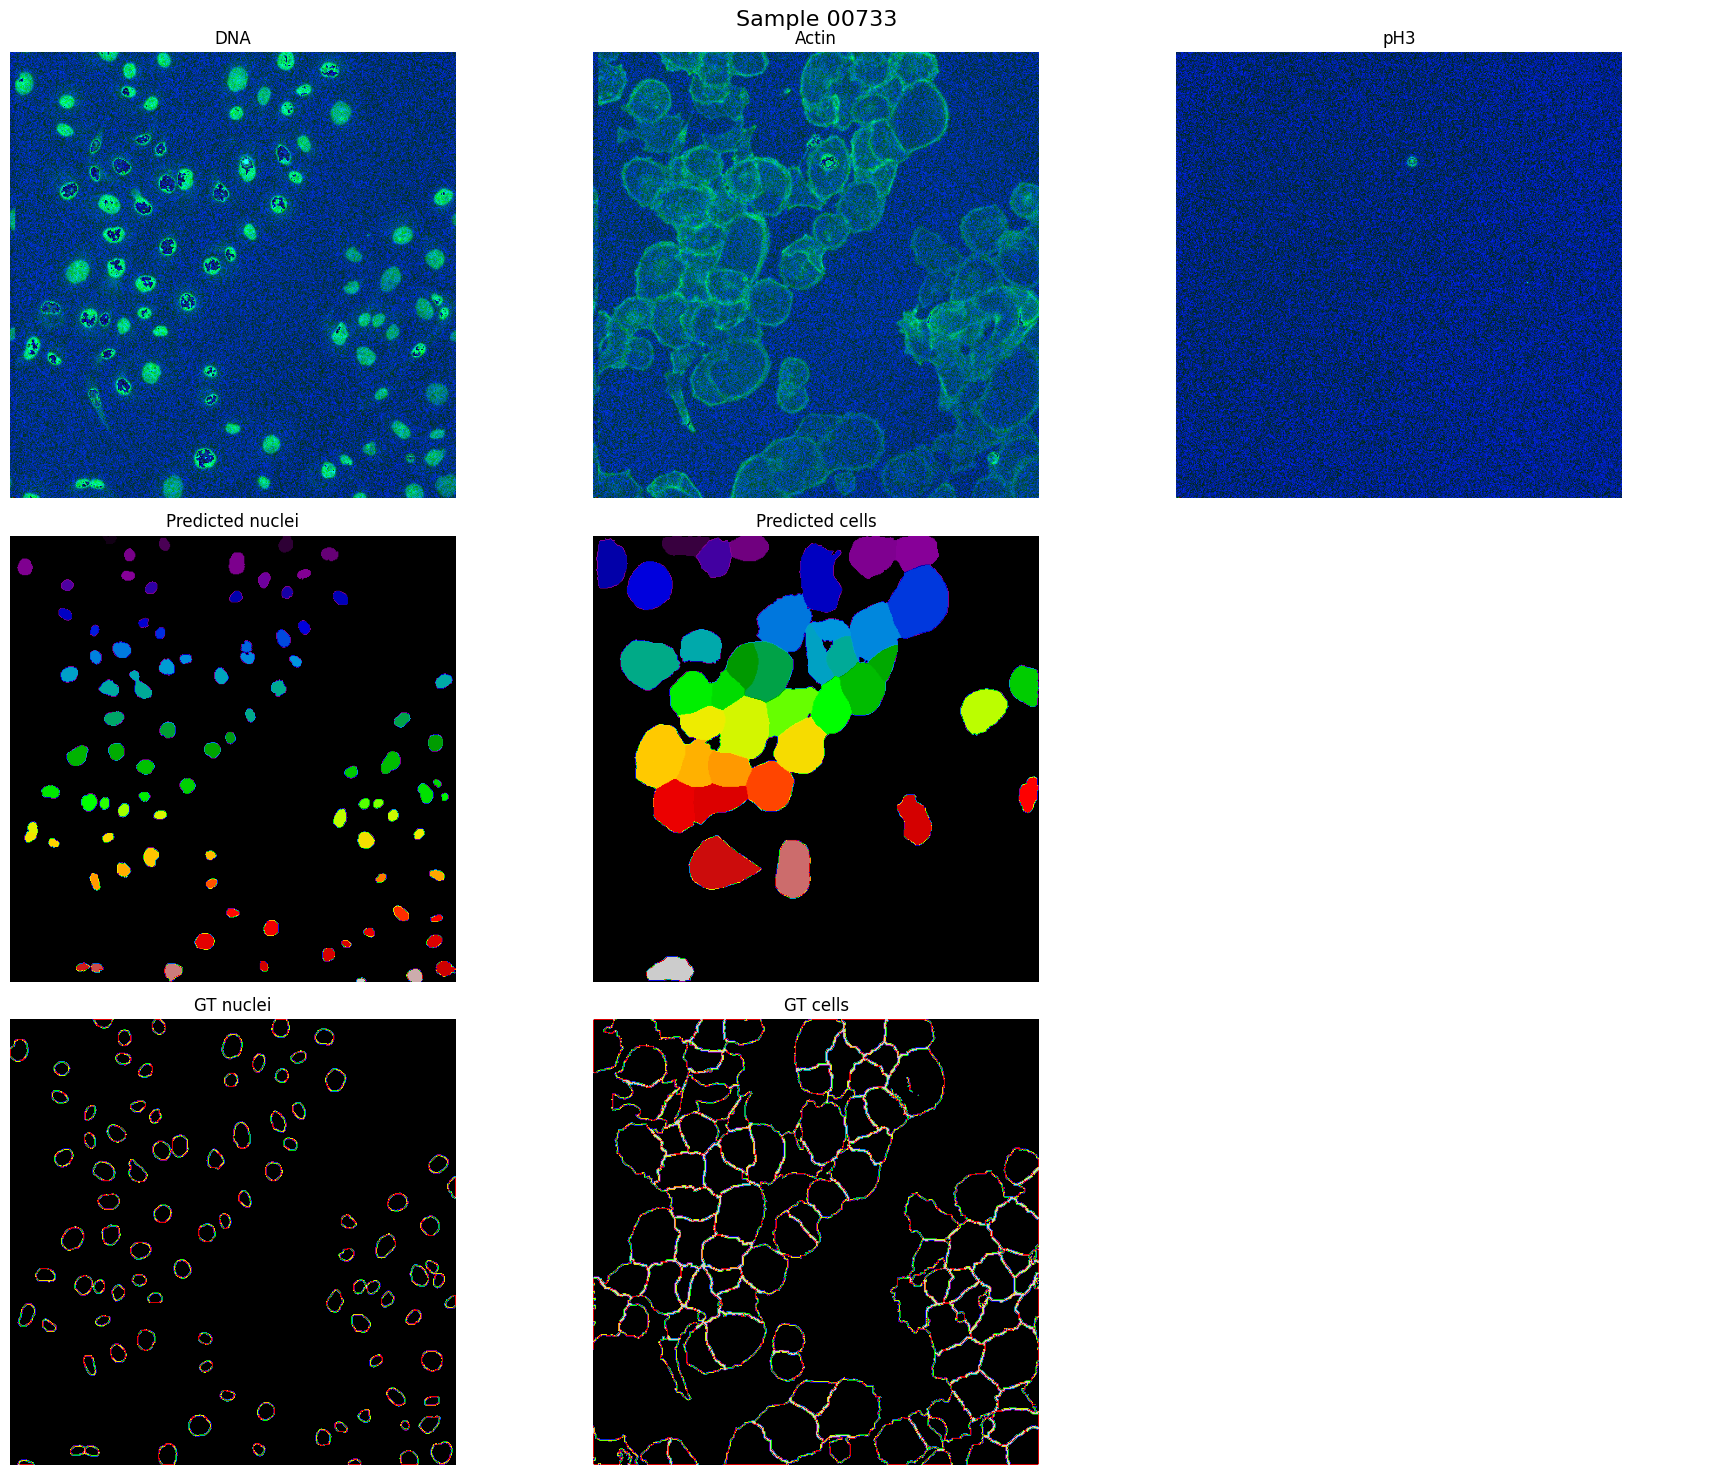

In [ ]:
def plot_on_axis(ax, data, title, cmap=None):
    """Helper to plot image or mask on axis."""
    if data is not None:
        ax.imshow(data, cmap=cmap)
        ax.set_title(title)
    else:
        ax.text(0.5, 0.5, f'Missing {title}', ha='center', va='center')
    ax.axis('off')

def compute_metrics(pred, gt):
    """Compute IoU and Dice metrics.
    Both pred and gt should be binary masks (0 for background, 1 for foreground).
    Therefore, we will binarize the predicted masks and fill holes in the ground truth masks before computing metrics.
    """
    if pred is None or gt is None:
        return None, None
    pred_binary = (pred > 0).astype(int)
    gt_binary = ndi.binary_fill_holes(gt > 0).astype(int)
    intersection = np.sum(pred_binary & gt_binary)
    union = np.sum(pred_binary | gt_binary)
    iou = intersection / union if union > 0 else 0
    dice = 2 * intersection / (np.sum(pred_binary) + np.sum(gt_binary)) if (np.sum(pred_binary) + np.sum(gt_binary)) > 0 else 0
    return iou, dice

def predict_sample(sample_id, model_nuc, model_cell):
    """Run predictions on a sample. Returns predictions and ground truth."""
    channels = load_sample_channels(sample_id)
    masks = load_ground_truth(sample_id)
    
    # Run predictions only if channels are available and not None
    nuclei_pred = None
    if channels.get('DNA') is not None:
        nuclei_pred = model_nuc.eval(channels['DNA'], diameter=None, normalize=True, flow_threshold=0.4, cellprob_threshold=0.0, min_size=5)[0]
    
    cells_pred = None
    if channels.get('actin') is not None:
        cells_pred = model_cell.eval(channels['actin'], diameter=None, normalize=True, flow_threshold=0.4, cellprob_threshold=0.0, min_size=5)[0]
    
    return {
        'sample_id': sample_id,
        'channels': channels,
        'nuclei_pred': nuclei_pred,
        'cells_pred': cells_pred,
        'masks_gt': masks
    }

def visualize_predictions(result):
    """Visualize predictions vs ground truth for a single sample."""
    sample_id = result['sample_id']
    channels = result['channels']
    nuclei_pred = result['nuclei_pred']
    cells_pred = result['cells_pred']
    masks_gt = result['masks_gt']
    
    # Print metrics
    if nuclei_pred is not None:
        iou, dice = compute_metrics(nuclei_pred, masks_gt.get('nuclei'))
        print(f"Nuclei: {nuclei_pred.max()} objects | IoU: {iou:.3f}, Dice: {dice:.3f}")
    if cells_pred is not None:
        iou, dice = compute_metrics(cells_pred, masks_gt.get('cells'))
        print(f"Cells: {cells_pred.max()} objects | IoU: {iou:.3f}, Dice: {dice:.3f}")
    
    # Visualize
    fig, axes = plt.subplots(3, 3, figsize=(18, 15))
    
    # Row 1: Input channels
    plot_on_axis(axes[0, 0], channels.get('DNA'), 'DNA')
    plot_on_axis(axes[0, 1], channels.get('actin'), 'Actin')
    plot_on_axis(axes[0, 2], channels.get('pH3'), 'pH3')
    
    # Row 2: Predictions
    plot_on_axis(axes[1, 0], nuclei_pred, 'Predicted nuclei', cmap='nipy_spectral')
    plot_on_axis(axes[1, 1], cells_pred, 'Predicted cells', cmap='nipy_spectral')
    axes[1, 2].axis('off')
    
    # Row 3: Ground truth
    plot_on_axis(axes[2, 0], masks_gt.get('nuclei'), 'GT nuclei', cmap='nipy_spectral')
    plot_on_axis(axes[2, 1], masks_gt.get('cells'), 'GT cells', cmap='nipy_spectral')
    axes[2, 2].axis('off')
    
    plt.suptitle(f'Sample {sample_id}', fontsize=16)
    plt.tight_layout()
    plt.show()

# Example: Single sample
print("=== Single Sample Prediction ===")
result = predict_sample('00733', model_nuclei, model_cells)
visualize_predictions(result)


In [45]:
# Batch predictions on all samples
print("=== Running predictions on ALL samples ===\n")

all_results = []
metrics_summary = []

for sample_id in available_samples:
    result = predict_sample(sample_id, model_nuclei, model_cells)
    all_results.append(result)
    
    # Calculate metrics
    nuc_iou, nuc_dice = compute_metrics(result['nuclei_pred'], result['masks_gt'].get('nuclei'))
    cell_iou, cell_dice = compute_metrics(result['cells_pred'], result['masks_gt'].get('cells'))
    
    metrics_summary.append({
        'sample_id': sample_id,
        'nuc_iou': nuc_iou,
        'nuc_dice': nuc_dice,
        'cell_iou': cell_iou,
        'cell_dice': cell_dice
    })

    # Print progress
    if nuc_iou is not None or cell_iou is not None:
        print(f"{sample_id}: Nuclei IoU={nuc_iou:.3f}, Dice={nuc_dice:.3f} | Cells IoU={cell_iou:.3f}, Dice={cell_dice:.3f}")

# Summary statistics
print("\n=== SUMMARY ===")
nuc_ious = [m['nuc_iou'] for m in metrics_summary if m['nuc_iou'] is not None]
nuc_dices = [m['nuc_dice'] for m in metrics_summary if m['nuc_dice'] is not None]
cell_ious = [m['cell_iou'] for m in metrics_summary if m['cell_iou'] is not None]
cell_dices = [m['cell_dice'] for m in metrics_summary if m['cell_dice'] is not None]

if nuc_ious:
    print(f"Nuclei - Mean IoU: {np.mean(nuc_ious):.3f} ± {np.std(nuc_ious):.3f}, Mean Dice: {np.mean(nuc_dices):.3f} ± {np.std(nuc_dices):.3f}")
if cell_ious:
    print(f"Cells  - Mean IoU: {np.mean(cell_ious):.3f} ± {np.std(cell_ious):.3f}, Mean Dice: {np.mean(cell_dices):.3f} ± {np.std(cell_dices):.3f}")


=== Running predictions on ALL samples ===

00733: Nuclei IoU=0.366, Dice=0.535 | Cells IoU=0.445, Dice=0.616
00734: Nuclei IoU=0.353, Dice=0.522 | Cells IoU=0.271, Dice=0.426
00735: Nuclei IoU=0.352, Dice=0.521 | Cells IoU=0.274, Dice=0.430
00736: Nuclei IoU=0.356, Dice=0.525 | Cells IoU=0.310, Dice=0.474
03997: Nuclei IoU=0.319, Dice=0.484 | Cells IoU=0.500, Dice=0.666
03998: Nuclei IoU=0.353, Dice=0.522 | Cells IoU=0.560, Dice=0.718
03999: Nuclei IoU=0.182, Dice=0.308 | Cells IoU=0.543, Dice=0.704
04000: Nuclei IoU=0.215, Dice=0.354 | Cells IoU=0.526, Dice=0.689
05621: Nuclei IoU=0.156, Dice=0.269 | Cells IoU=0.026, Dice=0.051
05622: Nuclei IoU=0.152, Dice=0.264 | Cells IoU=0.139, Dice=0.244
05623: Nuclei IoU=0.167, Dice=0.286 | Cells IoU=0.060, Dice=0.114
05624: Nuclei IoU=0.147, Dice=0.257 | Cells IoU=0.086, Dice=0.159
05897: Nuclei IoU=0.303, Dice=0.465 | Cells IoU=0.134, Dice=0.236
05898: Nuclei IoU=0.033, Dice=0.064 | Cells IoU=0.350, Dice=0.519
05899: Nuclei IoU=0.149, Dice=0.

Next step is hyperparameter optimizaiton. It can be done in a systematical approach.

Unfortunately the inference is  too costly to enable proper optimization process.